# 🚨 IncidentIQ — Multi-Agent DevOps Incident Analysis Suite

**Architecture:** 2-Phase, 13-Node LangGraph Pipeline  
**Phase I:** Deterministic Pre-processing (Nodes 1–4)  
**Phase II:** Agentic Reasoning (Nodes 5–13)  
**UI:** Streamlit Dashboard

---
> ⚠️ Run every cell **top to bottom, in order**. Never skip a cell.
>
> | Step | What it does |
> |------|-------------|
> | 1 | Install packages |
> | 2 | Set API keys |
> | 3 | Create folders |
> | 4 | Define GraphState |
> | 5 | Write Phase I agents (Nodes 1–4) |
> | 6 | Write Phase II agents (Nodes 5–10) |
> | 7 | Write Output agents (Nodes 11–13) |
> | 8 | Build Orchestrator |
> | 9 | Create demo log + runbooks |
> | 10 | Run full pipeline |
> | 11 | Write Streamlit UI |
> | 12 | Launch UI via ngrok |
> | 13 | View LangSmith traces |
> | 14 | Download project zip |

# 📖 Project Documentation: IncidentIQ Flow

### 🌊 System Overview
IncidentIQ is an automated **DevOps Incident Response Pipeline**. It uses **LangGraph** to coordinate 13 specialized agents that transform raw, chaotic log data into structured postmortem reports and actionable tickets.

---

### 🏗️ 13-Node Architecture

#### **Phase I: Deterministic Foundation (Nodes 1-4)**
*   **Node 1: Log Ingestor** — Entry point for raw `.log` or `.txt` telemetry.
*   **Node 2: Parser Agent** — Uses LLMs to convert unstructured text into standardized JSON schemas.
*   **Node 3: Signal Extractor** — Filters noise and identifies distinct 'anomaly signals'.
*   **Node 4: Evidence Clusterer** — Groups related signals into cohesive incidents (e.g., grouping database timeouts with high latency).

#### **Phase II: Agentic Reasoning (Nodes 5-10)**
*   **Node 5: RAG Retriever** — Queries local vector stores (`/runbooks`) for known fixes.
*   **Node 6: Classifier** — Determines severity (Critical/High/Med) and assigns categories.
*   **Node 7: Timeline Agent** — Reconstructs the exact sequence of events.
*   **Node 8: RCA Agent** — Investigates root causes based on log context and runbook data.
*   **Node 9: Remediation Agent** — Generates specific shell commands or config fixes.
*   **Node 10: Critic Agent** — A 'Judge' node that verifies analysis for hallucinations or errors.

#### **Phase III: Output & Automation (Nodes 11-13)**
*   **Node 11: Action Builder** — Automated dispatch to **Slack** and **JIRA**.
*   **Node 12: Report Builder** — Generates a final Markdown postmortem.
*   **Node 13: Eval Node** — Scores the entire run for accuracy and grounding.

---

### 🛠️ External Integrations
- **Slack**: Real-time severity-coded alerts (🔴 🟠 🟡).
- **JIRA**: Automated ticket creation for Critical and High severity issues.
- **LangSmith**: Full execution tracing for every node in the graph.
- **Ngrok**: Publicly accessible Streamlit dashboard.

## 📦 Step 1 — Install All Dependencies

In [54]:
import os

# 1. Install dependencies
!pip install -q langgraph langchain langchain-openai langchain-community
!pip install -q faiss-cpu chromadb sentence-transformers
!pip install -q streamlit plotly
!pip install -q python-dotenv requests tiktoken openai
!pip install -q langsmith
!pip install -q pyngrok

# 2. Define the requirements list
requirements = """langgraph
langchain
langchain-openai
langchain-community
faiss-cpu
chromadb
sentence-transformers
streamlit
plotly
python-dotenv
requests
tiktoken
openai
langsmith
pyngrok
langchain-text-splitters
pandas"""

# 3. Save to requirements.txt in the project folder
os.makedirs('incidentiq', exist_ok=True)
with open('incidentiq/requirements.txt', 'w') as f:
    f.write(requirements)

print("✅ All dependencies installed and requirements.txt saved in incidentiq/ folder.")

✅ All dependencies installed and requirements.txt saved in incidentiq/ folder.


## ⚙️ Step 2 — Configure API Keys

In [68]:
import os
import requests
from google.colab import userdata

# 1. Refresh Environment Variables from Secrets
def refresh_secrets():
    print("🔄 Refreshing environment variables from Colab Secrets...")
    keys = ["SLACK_WEBHOOK_URL", "JIRA_URL", "JIRA_EMAIL", "JIRA_API_TOKEN", "OPENROUTER_API_KEY", "LANGSMITH_API_KEY"]
    for key in keys:
        try:
            val = userdata.get(key)
            os.environ[key] = val
            # Map OpenRouter to OpenAI for the LangGraph agents
            if key == "OPENROUTER_API_KEY":
                os.environ["OPENAI_API_KEY"] = val
                os.environ["OPENAI_API_BASE"] = "https://openrouter.ai/api/v1"
            print(f"✅ {key} loaded.")
        except:
            print(f"⚠️ {key} not found in Secrets.")

# 2. Re-run Connectivity Test
def test_integrations():
    print("\n🔍 Testing Integration Connections...")

    # Test Slack
    slack_url = os.environ.get("SLACK_WEBHOOK_URL")
    if slack_url:
        try:
            res = requests.post(slack_url, json={"text": "🚀 IncidentIQ: Connection re-test successful!"}, timeout=5)
            if res.status_code == 200: print("✅ Slack: Connection Successful!")
            else: print(f"❌ Slack: Failed ({res.status_code})")
        except Exception as e: print(f"❌ Slack: Error - {e}")

    # Test JIRA
    jira_url = os.environ.get("JIRA_URL", "").rstrip("/")
    jira_email = os.environ.get("JIRA_EMAIL")
    jira_token = os.environ.get("JIRA_API_TOKEN")
    if all([jira_url, jira_email, jira_token]):
        try:
            res = requests.get(f"{jira_url}/rest/api/3/myself", auth=(jira_email, jira_token), timeout=10)
            if res.status_code == 200: print(f"✅ JIRA: Connection Successful! (Authenticated as {res.json().get('displayName')})")
            else: print(f"❌ JIRA: Failed ({res.status_code})")
        except Exception as e: print(f"❌ JIRA: Error - {e}")

refresh_secrets()
test_integrations()

🔄 Refreshing environment variables from Colab Secrets...
✅ SLACK_WEBHOOK_URL loaded.
✅ JIRA_URL loaded.
✅ JIRA_EMAIL loaded.
✅ JIRA_API_TOKEN loaded.
✅ OPENROUTER_API_KEY loaded.
✅ LANGSMITH_API_KEY loaded.

🔍 Testing Integration Connections...
✅ Slack: Connection Successful!
✅ JIRA: Connection Successful! (Authenticated as Bhavna Rathi)


In [70]:
import os

readme_path = 'incidentiq/README.md'

# New content as requested
setup_instructions = """
## ⚙️ Setup — API Keys

This project reads all credentials from **Colab Secrets** (never hardcoded).

Add these secrets in Colab (🔑 icon → left panel → Add new secret):

| Secret name | Where to get it |
|---|---|
| `OPENROUTER_API_KEY` | openrouter.ai/keys |
| `LANGSMITH_API_KEY` | smith.langchain.com → Settings → API Keys |
| `SLACK_WEBHOOK_URL` | api.slack.com/apps → Incoming Webhooks |
| `JIRA_URL` | https://yourname.atlassian.net |
| `JIRA_EMAIL` | your Atlassian account email |
| `JIRA_API_TOKEN` | atlassian.net → Account Settings → Security → API tokens |
"""

# Replace the content with the standard header + instructions
with open(readme_path, 'w') as f:
    f.write('# 🚨 IncidentIQ — Multi-Agent DevOps Incident Analysis Suite\n' + setup_instructions)

print(f"✅ {readme_path} updated with safe API key instructions.")

✅ incidentiq/README.md updated with safe API key instructions.


## 🗂️ Step 3 — Create Project Folder Structure

In [4]:
import os

dirs = [
    "incidentiq", "incidentiq/phase1_agents", "incidentiq/phase2_agents",
    "incidentiq/output_agents", "incidentiq/state", "incidentiq/rag",
    "incidentiq/tools", "incidentiq/ui", "incidentiq/runbooks",
    "incidentiq/sample_logs", "incidentiq/evals", "incidentiq/exports",
]
for d in dirs:
    os.makedirs(d, exist_ok=True)
    if not any(d.endswith(x) for x in ["sample_logs", "runbooks", "exports"]):
        open(f"{d}/__init__.py", "w").close()

print("✅ Folder structure created:")
for d in dirs:
    print(f"   📁 {d}")

✅ Folder structure created:
   📁 incidentiq
   📁 incidentiq/phase1_agents
   📁 incidentiq/phase2_agents
   📁 incidentiq/output_agents
   📁 incidentiq/state
   📁 incidentiq/rag
   📁 incidentiq/tools
   📁 incidentiq/ui
   📁 incidentiq/runbooks
   📁 incidentiq/sample_logs
   📁 incidentiq/evals
   📁 incidentiq/exports


## 🧠 Step 4 — Define Shared GraphState

In [5]:
state_code = '''
from typing import TypedDict, List, Dict, Any, Optional

class IncidentResult(TypedDict):
    incident_id: str
    category: str
    severity: str
    confidence: float
    title: str
    root_cause: Optional[Dict[str, Any]]
    remediation: Optional[Dict[str, Any]]

class GraphState(TypedDict):
    # Phase I
    raw_logs: str
    log_events: List[Any]
    signals: List[Any]
    clusters: List[Any]
    # Phase II
    rag_enriched_data: List[Any]
    incidents: List[IncidentResult]
    # Output
    action_payload: Dict[str, Any]
    slack_sent: bool
    jira_tickets: List[Dict[str, Any]]
    report: Dict[str, Any]
    eval_scores: List[Dict[str, Any]]
    # Meta
    run_id: str
    errors: List[str]
'''
with open("incidentiq/state/graph_state.py", "w") as f:
    f.write(state_code)
print("✅ GraphState defined with all required fields.")

✅ GraphState defined with all required fields.


## 🔵 Step 5 — Phase I Agents (Nodes 1–4)

In [20]:
# ── Node 1: Log Ingestor ──────────────────────────────────────
node1 = '''
import uuid
from incidentiq.state.graph_state import GraphState

def log_ingestor(state: GraphState) -> GraphState:
    print("[Node 1] Log ingestor running...")
    raw = state.get("raw_logs", "")
    if not raw:
        state["errors"] = state.get("errors", []) + ["No logs provided"]
        return state
    state["run_id"] = state.get("run_id") or str(uuid.uuid4())[:8]
    print(f"[Node 1] Ingested {len(raw.splitlines())} lines of logs.")
    return state
'''

# ── Node 2: Parser Agent ──────────────────────────────────────
node2 = '''
import json
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from incidentiq.state.graph_state import GraphState

PARSER_SYSTEM = """You are a DevOps log parser. Convert raw log lines into structured JSON.
Return a JSON object with key \"events\" containing an array of LogEvent objects.
Each object must have: timestamp, level (DEBUG/INFO/WARN/ERROR/CRITICAL),
service, message, raw, trace_id (or null). Return ONLY the JSON object."""

def parser_agent(state: GraphState) -> GraphState:
    print("[Node 2] Parser agent running...")
    llm = ChatOpenAI(model="gpt-4o-mini",
                     model_kwargs={"response_format": {"type": "json_object"}},
                     temperature=0)
    raw  = state["raw_logs"].strip()
    prompt = "Parse these log lines into the events array:\\n\\n" + raw
    resp = llm.invoke([SystemMessage(content=PARSER_SYSTEM), HumanMessage(content=prompt)])
    try:
        parsed = json.loads(resp.content)
        all_events = parsed if isinstance(parsed, list) else parsed.get("events", [])
    except Exception as e:
        print(f"[Node 2] Parse error: {e}")
        all_events = []
    state["log_events"] = all_events
    print(f"[Node 2] Parsed {len(all_events)} log events.")
    return state
'''

with open("incidentiq/phase1_agents/node1_log_ingestor.py", "w") as f: f.write(node1)
with open("incidentiq/phase1_agents/node2_parser_agent.py", "w") as f: f.write(node2)
print("✅ Nodes 1 & 2 saved.")

✅ Nodes 1 & 2 saved.


In [23]:
# ── Node 3: Signal Extractor ──────────────────────────────────
node3 = '''
import json
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from incidentiq.state.graph_state import GraphState

SIGNAL_SYSTEM = """You are a DevOps signal extractor. Identify distinct incident signals.
Return JSON: {\"signals\": [{\"signal_id\", \"category\", \"service\", \"events\", \"count\"}]}"""

def signal_extractor(state: GraphState) -> GraphState:
    print("[Node 3] Signal extractor running...")
    llm = ChatOpenAI(model="gpt-4o",
                     model_kwargs={"response_format": {"type": "json_object"}},
                     temperature=0)
    events_text = json.dumps(state["log_events"][:100])
    resp = llm.invoke([
        SystemMessage(content=SIGNAL_SYSTEM),
        HumanMessage(content="Extract signals from:\\n" + events_text)
    ])
    state["signals"] = json.loads(resp.content).get("signals", [])
    print(f"[Node 3] Extracted {len(state['signals'])} signals.")
    return state
'''

# ── Node 4: Evidence Clusterer ────────────────────────────────
node4 = '''
import json
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from incidentiq.state.graph_state import GraphState

CLUSTER_SYSTEM = """You are a DevOps clusterer. Group signals into EvidenceClusters.
For each cluster provide: cluster_id (UUID), candidate_category, signature,
affected_services (list), total_weight (0-10), evidence.
Return JSON: {\"clusters\": [...]}"""

def clusterer(state: GraphState) -> GraphState:
    print("[Node 4] Evidence Clusterer running...")
    llm = ChatOpenAI(model="gpt-4o",
                     model_kwargs={"response_format": {"type": "json_object"}},
                     temperature=0)
    signals_text = json.dumps(state.get("signals", []))
    resp = llm.invoke([
        SystemMessage(content=CLUSTER_SYSTEM),
        HumanMessage(content="Create EvidenceClusters from:\\n" + signals_text)
    ])
    state["clusters"] = json.loads(resp.content).get("clusters", [])
    print(f"[Node 4] Generated {len(state['clusters'])} standardized EvidenceClusters.")
    return state
'''

with open("incidentiq/phase1_agents/node3_signal_extractor.py", "w") as f: f.write(node3)
with open("incidentiq/phase1_agents/node4_clusterer.py", "w") as f: f.write(node4)
print("✅ Nodes 3 & 4 fixed and saved.")

✅ Nodes 3 & 4 fixed and saved.


## 🟣 Step 6 — Phase II Agents (Nodes 5–10)

In [24]:
# ── Node 5: RAG Retriever ─────────────────────────────────────
node5 = '''
import os, json
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.messages import SystemMessage, HumanMessage
from incidentiq.state.graph_state import GraphState

RUNBOOKS_DIR = "incidentiq/runbooks"
_vectorstore = None

def _get_vectorstore():
    global _vectorstore
    if _vectorstore is not None: return _vectorstore
    embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
    if not [f for f in os.listdir(RUNBOOKS_DIR) if f.endswith(".txt")]:
        with open(RUNBOOKS_DIR + "/default.txt", "w") as rb:
            rb.write("AUTH_FAILURE: Check gateway logs. Rotate tokens.\\n")
            rb.write("TIMEOUT: Check DB pool. Restart service.\\n")
            rb.write("MEMORY: Check heap. Scale pod resources.\\n")
            rb.write("REDIS_OOM: kubectl top pods. Flush volatile keys.\\n")
    loader = DirectoryLoader(RUNBOOKS_DIR, glob="*.txt", loader_cls=TextLoader)
    chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(loader.load())
    _vectorstore = FAISS.from_documents(chunks, embeddings)
    return _vectorstore

RAG_SYSTEM = """You are a RAG structurer. Return JSON: {\"result\": {\"cluster_id\", \"diagnostics\", \"remediation\", \"safety_notes\"}}"""

def rag_retriever(state: GraphState) -> GraphState:
    print("[Node 5] RAG retriever running...")
    vs = _get_vectorstore()
    llm = ChatOpenAI(model="gpt-4o-mini",
                     model_kwargs={"response_format": {"type": "json_object"}},
                     temperature=0)
    enriched = []
    for cluster in state.get("clusters", []):
        docs = vs.similarity_search(cluster.get("signature", ""), k=2)
        context = "Cluster: " + json.dumps(cluster) + "\\nContext: " + str(docs)
        resp = llm.invoke([SystemMessage(content=RAG_SYSTEM), HumanMessage(content=context)])
        res = json.loads(resp.content).get("result", {})
        res["cluster_id"] = cluster.get("cluster_id")
        enriched.append(res)
    state["rag_enriched_data"] = enriched
    print(f"[Node 5] Runbook context attached to {len(enriched)} clusters.")
    return state
'''

# ── Node 6: Classifier Agent ──────────────────────────────────
node6 = '''
import json, uuid
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from incidentiq.state.graph_state import GraphState

CLASSIFIER_SYSTEM = """Transform EvidenceClusters into IncidentResult objects.
severity must be one of: Critical, High, Medium, Low.
Return JSON: {\"incidents\": [{\"incident_id\", \"category\", \"severity\", \"confidence\", \"title\"}]}"""

def classifier_agent(state: GraphState) -> GraphState:
    print("[Node 6] Classifier agent running...")
    llm = ChatOpenAI(model="gpt-4o",
                     model_kwargs={"response_format": {"type": "json_object"}},
                     temperature=0)
    payload = json.dumps({"clusters": state.get("clusters", [])})
    resp = llm.invoke([SystemMessage(content=CLASSIFIER_SYSTEM), HumanMessage(content=payload)])
    incidents = json.loads(resp.content).get("incidents", [])
    for inc in incidents:
        if "incident_id" not in inc: inc["incident_id"] = str(uuid.uuid4())[:8]
    state["incidents"] = incidents
    print(f"[Node 6] Created {len(incidents)} Incident objects.")
    return state
'''

with open("incidentiq/phase2_agents/node5_rag_retriever.py", "w") as f: f.write(node5)
with open("incidentiq/phase2_agents/node6_classifier_agent.py", "w") as f: f.write(node6)
print("✅ Nodes 5 & 6 fixed and saved.")

✅ Nodes 5 & 6 fixed and saved.


In [9]:
# ── Node 7: Timeline Agent ────────────────────────────────────
node7 = '''
from incidentiq.state.graph_state import GraphState

def timeline_agent(state: GraphState) -> GraphState:
    incidents = state.get("incidents", [])
    print(f"[Node 7] Timeline agent processing {len(incidents)} incidents...")
    return state
'''

# ── Node 8: RCA Agent ─────────────────────────────────────────
node8 = '''
from incidentiq.state.graph_state import GraphState

def rca_agent(state: GraphState) -> GraphState:
    incidents = state.get("incidents", [])
    print(f"[Node 8] RCA agent processing {len(incidents)} incidents...")
    return state
'''

with open("incidentiq/phase2_agents/node7_timeline_agent.py", "w") as f: f.write(node7)
with open("incidentiq/phase2_agents/node8_rca_agent.py", "w") as f: f.write(node8)
print("✅ Nodes 7 & 8 saved.")

✅ Nodes 7 & 8 saved.


In [10]:
# ── Node 9: Remediation Agent ─────────────────────────────────
node9 = '''
from incidentiq.state.graph_state import GraphState

def remediation_agent(state: GraphState) -> GraphState:
    incidents = state.get("incidents", [])
    print(f"[Node 9] Remediation agent processing {len(incidents)} incidents...")
    return state
'''

# ── Node 10: Critic Agent ─────────────────────────────────────
node10 = '''
import json
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from incidentiq.state.graph_state import GraphState

CRITIC_SYSTEM = """You are a QA critic. Review the incident analysis for accuracy and grounding.
Return JSON: {\"critic_scores\": [{\"incident_id\", \"grounding\": 0-10, \"accuracy\": 0-10, \"flagged\": bool}]}"""

def critic_agent(state: GraphState) -> GraphState:
    incidents = state.get("incidents", [])
    print(f"[Node 10] Critic agent reviewing {len(incidents)} incidents...")
    if not incidents: return state
    llm = ChatOpenAI(model="gpt-4o",
                     model_kwargs={"response_format": {"type": "json_object"}},
                     temperature=0)
    resp = llm.invoke([
        SystemMessage(content=CRITIC_SYSTEM),
        HumanMessage(content=json.dumps({"incidents": incidents}))
    ])
    try:
        scores = json.loads(resp.content).get("critic_scores", [])
        flagged = sum(1 for s in scores if s.get("flagged"))
        print(f"[Node 10] Critic reviewed {len(scores)} outputs — {flagged} flagged.")
    except:
        pass
    return state
'''

with open("incidentiq/phase2_agents/node9_remediation_agent.py", "w") as f: f.write(node9)
with open("incidentiq/phase2_agents/node10_critic_agent.py", "w") as f: f.write(node10)
print("✅ Nodes 9 & 10 saved.")

✅ Nodes 9 & 10 saved.


## 🟠 Step 7 — Output Nodes (Nodes 11–13)

In [26]:
# ── Node 11: Action Builder (Slack + JIRA) ────────────────────
node11 = """
import os
import requests
from incidentiq.state.graph_state import GraphState

def action_builder(state: GraphState) -> GraphState:
    incidents  = state.get("incidents", [])
    print(f"[Node 11] Action Builder processing {len(incidents)} incidents...")

    slack_url  = os.environ.get("SLACK_WEBHOOK_URL", "")
    jira_url   = os.environ.get("JIRA_URL", "").rstrip("/")
    jira_email = os.environ.get("JIRA_EMAIL", "")
    jira_token = os.environ.get("JIRA_API_TOKEN", "")
    project    = os.environ.get("JIRA_PROJECT_KEY", "KAN")

    emoji_map  = {"Critical": ":red_circle:", "High": ":large_orange_circle:",
                  "Medium": ":large_yellow_circle:", "Low": ":white_circle:"}
    actions, tickets, slack_sent = [], [], False

    for inc in incidents:
        severity = inc.get("severity", "Low")
        title    = inc.get("title", inc.get("category", "Unknown"))
        emoji    = emoji_map.get(severity, ":white_circle:")

        # Slack
        if slack_url:
            try:
                r = requests.post(slack_url,
                    json={"text": emoji + " *" + severity + "* — " + title},
                    timeout=5)
                print(f"[Slack] {severity} — status: {r.status_code}")
                if r.status_code == 200: slack_sent = True
            except Exception as e:
                print(f"[Slack] Error: {e}")

        # JIRA — Critical & High only
        if severity in ["Critical", "High"] and jira_url and jira_token:
            try:
                r = requests.post(
                    jira_url + "/rest/api/3/issue",
                    json={"fields": {
                        "project":   {"key": project},
                        "summary":   "[IncidentIQ] " + severity + " — " + title,
                        "issuetype": {"name": "Task"},
                        "priority":  {"name": "Highest" if severity == "Critical" else "High"},
                        "labels":    ["incidentiq"]
                    }},
                    auth=(jira_email, jira_token),
                    headers={"Content-Type": "application/json"},
                    timeout=10
                )
                if r.status_code == 201:
                    t = r.json()
                    tickets.append(t)
                    print(f"[JIRA] Ticket created: {t.get('key')}")
                else:
                    print(f"[JIRA] Failed {r.status_code}: {r.text[:120]}")
            except Exception as e:
                print(f"[JIRA] Error: {e}")

        actions.append({"incident_id": inc.get("incident_id"),
                        "severity": severity, "status": "PROCESSED"})

    state["action_payload"] = {"actions": actions}
    state["slack_sent"]     = slack_sent
    state["jira_tickets"]   = tickets
    print(f"[Node 11] Done — {len(actions)} actions | {len(tickets)} JIRA | Slack: {slack_sent}")
    return state
"""
with open("incidentiq/output_agents/node11_action_builder.py", "w") as f: f.write(node11)

# ── Node 12: Report Builder ───────────────────────────────────
node12 = '''
import os
from datetime import datetime
from incidentiq.state.graph_state import GraphState

def report_builder(state: GraphState) -> GraphState:
    incidents = state.get("incidents", [])
    print(f"[Node 12] Report Builder processing {len(incidents)} incidents...")
    now = datetime.now().strftime("%Y-%m-%d %H:%M")
    run_id = state.get("run_id", "N/A")
    md  = "# IncidentIQ Postmortem — " + now + "\\n\\n"
    md += "**Run ID:** `" + str(run_id) + "`  \\n"
    md += "**Total Incidents:** " + str(len(incidents)) + "\\n\\n"
    for inc in incidents:
        sev      = inc.get("severity", "N/A")
        title    = inc.get("title", "Untitled")
        category = inc.get("category", "N/A")
        conf     = str(inc.get("confidence", 0))
        md += "### [" + sev + "] " + title + "\\n"
        md += "**Category:** " + category + " | **Confidence:** " + conf + "\\n\\n"
    os.makedirs("incidentiq/exports", exist_ok=True)
    with open("incidentiq/exports/postmortem.md", "w") as f: f.write(md)
    state["report"] = {"markdown": md, "timestamp": now}
    print("[Node 12] Report saved ✅")
    return state
'''

# ── Node 13: Eval Node ────────────────────────────────────────
node13 = '''
import json
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from incidentiq.state.graph_state import GraphState

def eval_node(state: GraphState) -> GraphState:
    incidents = state.get("incidents", [])
    print(f"[Node 13] Eval node processing {len(incidents)} incidents...")
    llm = ChatOpenAI(model="gpt-4o-mini",
                     model_kwargs={"response_format": {"type": "json_object"}},
                     temperature=0)
    payload = json.dumps(incidents[:5])
    resp = llm.invoke([
        SystemMessage(content="Evaluate this incident analysis. Return JSON: {\\"accuracy\\": 0-10, \\"grounding\\": 0-10, \\"notes\\": \\"...\\"}"),
        HumanMessage(content=payload)
    ])
    result = json.loads(resp.content)
    state["eval_scores"] = [result]
    acc = result.get("accuracy", 0)
    grn = result.get("grounding", 0)
    print(f"[Node 13] Eval complete ✅ — Accuracy: " + str(acc) + "/10, Grounding: " + str(grn) + "/10")
    return state
'''

with open("incidentiq/output_agents/node12_report_builder.py", "w") as f: f.write(node12)
with open("incidentiq/output_agents/node13_eval_node.py", "w") as f: f.write(node13)
print("✅ Nodes 11, 12 & 13 fixed and saved.")

✅ Nodes 11, 12 & 13 fixed and saved.


## 🔗 Step 8 — Build the LangGraph Orchestrator

In [21]:
orchestrator_code = '''
from langgraph.graph import StateGraph, END
from incidentiq.state.graph_state import GraphState
from incidentiq.phase1_agents.node1_log_ingestor import log_ingestor
from incidentiq.phase1_agents.node2_parser_agent import parser_agent
from incidentiq.phase1_agents.node3_signal_extractor import signal_extractor
from incidentiq.phase1_agents.node4_clusterer import clusterer
from incidentiq.phase2_agents.node5_rag_retriever import rag_retriever
from incidentiq.phase2_agents.node6_classifier_agent import classifier_agent
from incidentiq.phase2_agents.node7_timeline_agent import timeline_agent
from incidentiq.phase2_agents.node8_rca_agent import rca_agent
from incidentiq.phase2_agents.node9_remediation_agent import remediation_agent
from incidentiq.phase2_agents.node10_critic_agent import critic_agent
from incidentiq.output_agents.node11_action_builder import action_builder
from incidentiq.output_agents.node12_report_builder import report_builder
from incidentiq.output_agents.node13_eval_node import eval_node

def build_graph():
    graph = StateGraph(GraphState)
    graph.add_node("log_ingestor",      log_ingestor)
    graph.add_node("parser_agent",      parser_agent)
    graph.add_node("signal_extractor",  signal_extractor)
    graph.add_node("clusterer",         clusterer)
    graph.add_node("rag_retriever",     rag_retriever)
    graph.add_node("classifier_agent",  classifier_agent)
    graph.add_node("timeline_agent",    timeline_agent)
    graph.add_node("rca_agent",         rca_agent)
    graph.add_node("remediation_agent", remediation_agent)
    graph.add_node("critic_agent",      critic_agent)
    graph.add_node("action_builder",    action_builder)
    graph.add_node("report_builder",    report_builder)
    graph.add_node("eval_node",         eval_node)

    graph.set_entry_point("log_ingestor")
    graph.add_edge("log_ingestor",      "parser_agent")
    graph.add_edge("parser_agent",      "signal_extractor")
    graph.add_edge("signal_extractor",  "clusterer")
    graph.add_edge("clusterer",         "rag_retriever")
    graph.add_edge("rag_retriever",     "classifier_agent")
    graph.add_edge("classifier_agent",  "timeline_agent")
    graph.add_edge("timeline_agent",    "rca_agent")
    graph.add_edge("rca_agent",         "remediation_agent")
    graph.add_edge("remediation_agent", "critic_agent")
    graph.add_edge("critic_agent",      "action_builder")
    graph.add_edge("action_builder",    "report_builder")
    graph.add_edge("report_builder",    "eval_node")
    graph.add_edge("eval_node",         END)
    return graph.compile()
'''
with open("incidentiq/orchestrator.py", "w") as f: f.write(orchestrator_code)
print("✅ Orchestrator saved — all 13 nodes wired correctly.")

✅ Orchestrator saved — all 13 nodes wired correctly.


## 🎭 Step 9 — Demo Log File + Runbooks

In [13]:
demo_log = """2024-01-15 14:01:12 INFO  auth-service    [trace_id=abc123] Starting authentication service
2024-01-15 14:01:45 WARN  auth-service    [trace_id=abc123] Token validation latency high: 850ms
2024-01-15 14:02:01 ERROR auth-service    [trace_id=abc123] JWT validation failed: token expired for user_id=8821
2024-01-15 14:02:01 ERROR auth-service    [trace_id=abc123] JWT validation failed: token expired for user_id=9034
2024-01-15 14:02:02 ERROR auth-service    [trace_id=abc123] JWT validation failed: token expired for user_id=7741
2024-01-15 14:02:03 CRITICAL auth-service [trace_id=abc123] Auth service rejecting all requests — Redis cache unreachable
java.lang.RuntimeException: Connection refused: redis:6379
  at AuthService.validateToken(AuthService.java:142)
2024-01-15 14:02:05 ERROR redis-cluster   [trace_id=def456] CLUSTERDOWN: The cluster is down
2024-01-15 14:02:06 ERROR redis-cluster   [trace_id=def456] Failed to PING node redis-1: Connection timeout after 5000ms
2024-01-15 14:02:06 ERROR redis-cluster   [trace_id=def456] Failed to PING node redis-2: Connection timeout after 5000ms
2024-01-15 14:02:08 WARN  api-gateway     [trace_id=abc123] Upstream auth-service returning 503 — circuit breaker OPEN
2024-01-15 14:02:09 ERROR api-gateway     [trace_id=abc123] All auth requests failing — rejecting downstream traffic
2024-01-15 14:02:10 ERROR payment-service [trace_id=ghi789] Cannot validate user session — auth-service unavailable
2024-01-15 14:02:10 ERROR payment-service [trace_id=ghi789] Transaction aborted for order_id=TXN-55821
2024-01-15 14:02:12 CRITICAL payment-service [trace_id=ghi789] Payment processing halted — 0% success rate
2024-01-15 14:02:15 WARN  node-1          Disk usage at 94% on /var/log — log rotation not running
2024-01-15 14:02:20 ERROR node-1          OOMKilled: redis-1 container killed — memory limit 2Gi exceeded
2024-01-15 14:02:21 ERROR k8s-scheduler   Pod redis-1 evicted. Reason: OOMKilled
2024-01-15 14:02:22 ERROR k8s-scheduler   Pod redis-2 evicted. Reason: OOMKilled
2024-01-15 14:02:25 CRITICAL order-service  [trace_id=jkl000] Dependency auth-service UNREACHABLE — all orders failing
2024-01-15 14:02:26 ERROR order-service   [trace_id=jkl000] Failed to create order for customer_id=C-3341
2024-01-15 14:03:00 INFO  alertmanager    PagerDuty alert fired: P1-CRITICAL — Auth service down
2024-01-15 14:03:01 INFO  alertmanager    Slack notification sent to #incidents channel
"""
with open("incidentiq/sample_logs/demo_incident.log", "w") as f: f.write(demo_log)

redis_runbook = """REDIS_OOM:
1. kubectl top pods — identify the OOMing pod.
2. Check memory limits in helm chart.
3. Verify memory leak or key spike.
4. Flush volatile keys or restart with higher limits.

REDIS_CLUSTER_DOWN:
1. Check connectivity between redis nodes.
2. Verify master quorum: redis-cli cluster info.
3. Check pod logs: kubectl logs redis-0.
4. Restart cluster: kubectl rollout restart statefulset/redis.
"""
with open("incidentiq/runbooks/redis_runbook.txt", "w") as f: f.write(redis_runbook)

auth_runbook = """AUTH_FAILURE:
1. Check API gateway logs for auth errors.
2. Rotate tokens: kubectl rollout restart deploy/auth-service.
3. Verify IAM policies and token expiry config.
4. Check Redis connectivity from auth-service.
"""
with open("incidentiq/runbooks/auth_runbook.txt", "w") as f: f.write(auth_runbook)

print(f"✅ Demo log created ({len(demo_log.splitlines())} lines)")
print("✅ Runbooks created: redis_runbook.txt, auth_runbook.txt")

✅ Demo log created (24 lines)
✅ Runbooks created: redis_runbook.txt, auth_runbook.txt


## ▶️ Step 10 — Run the Full Pipeline

In [27]:
import sys

# ── 1. Clear ALL cached incidentiq modules ─────────────────────
for mod in list(sys.modules.keys()):
    if "incidentiq" in mod:
        del sys.modules[mod]
print("✅ Module cache cleared")

# ── 2. Rebuild graph from fresh files ─────────────────────────
from incidentiq.orchestrator import build_graph
graph = build_graph()
print("✅ Graph rebuilt\n")

# ── 3. Load demo log ──────────────────────────────────────────
with open("incidentiq/sample_logs/demo_incident.log") as f:
    raw_logs = f.read()

# ── 4. Define initial state (ALL fields required) ─────────────
initial_state = {
    "raw_logs":          raw_logs,
    "log_events":        [],
    "signals":           [],
    "clusters":          [],
    "rag_enriched_data": [],
    "incidents":         [],
    "action_payload":    {},
    "slack_sent":        False,
    "jira_tickets":      [],
    "report":            {},
    "eval_scores":       [],
    "run_id":            "demo-run",
    "errors":            [],
}

# ── 5. Invoke pipeline ────────────────────────────────────────
print("🚀 Running pipeline...\n")
final_result = graph.invoke(initial_state)

# ── 6. Print final results ────────────────────────────────────
print("\n" + "="*45)
print(f"✅ Incidents found    : {len(final_result.get('incidents', []))}")
print(f"✅ Actions generated  : {len(final_result.get('action_payload', {}).get('actions', []))}")
print(f"✅ Slack sent         : {final_result.get('slack_sent')}")
print(f"✅ JIRA tickets       : {[t.get('key') for t in final_result.get('jira_tickets', [])]}")
print(f"✅ Report saved       : {'Yes' if final_result.get('report') else 'No'}")
print(f"✅ Eval scores        : {final_result.get('eval_scores', [])}")
print("\n── Incident breakdown ──")
for inc in final_result.get("incidents", []):
    print(f"  [{inc.get('severity')}] {inc.get('title', inc.get('category'))}")

✅ Module cache cleared
✅ Graph rebuilt

🚀 Running pipeline...

[Node 1] Log ingestor running...
[Node 1] Ingested 24 lines of logs.
[Node 2] Parser agent running...
[Node 2] Parsed 22 log events.
[Node 3] Signal extractor running...
[Node 3] Extracted 9 signals.
[Node 4] Evidence Clusterer running...
[Node 4] Generated 3 standardized EvidenceClusters.
[Node 5] RAG retriever running...
[Node 5] Runbook context attached to 3 clusters.
[Node 6] Classifier agent running...
[Node 6] Created 3 Incident objects.
[Node 7] Timeline agent processing 3 incidents...
[Node 8] RCA agent processing 3 incidents...
[Node 9] Remediation agent processing 3 incidents...
[Node 10] Critic agent reviewing 3 incidents...
[Node 10] Critic reviewed 3 outputs — 0 flagged.
[Node 11] Action Builder processing 3 incidents...
[Slack] Critical — status: 200
[JIRA] Ticket created: KAN-52
[Slack] High — status: 200
[JIRA] Ticket created: KAN-53
[Slack] Medium — status: 200
[Node 11] Done — 3 actions | 2 JIRA | Slack: T

## 🖥️ Step 11 — Write Streamlit UI

In [47]:
streamlit_app = '''
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json, sys, os
sys.path.insert(0, "/content")

from incidentiq.orchestrator import build_graph

st.set_page_config(page_title="IncidentIQ", page_icon="🚨", layout="wide")

# ── Custom CSS ────────────────────────────────────────────────
st.markdown("""
<style>
.metric-card {
    background: #1e1e2e; border: 1px solid #3d3d5c;
    border-radius: 12px; padding: 1rem 1.25rem; text-align: center;
}
.metric-label { font-size: 12px; color: #888; text-transform: uppercase; letter-spacing: 1px; margin-bottom: 4px; }
.metric-value { font-size: 32px; font-weight: 700; color: #fff; }
.metric-critical { border-left: 4px solid #ff4444; }
.metric-high     { border-left: 4px solid #ff8800; }
.metric-medium   { border-left: 4px solid #ffcc00; }
.metric-good     { border-left: 4px solid #00cc66; }
.inc-card{background:#1a1a2e;border-radius:10px;padding:1rem 1.2rem;margin-bottom:8px;border-left:4px solid #555}
.conf-bar{height:5px;border-radius:3px;background:#333;margin-top:4px;overflow:hidden}
.sev-badge{font-size:11px;font-weight:600;padding:3px 10px;border-radius:100px;display:inline-block}
.badge-critical{background:#ff2222;color:#fff}
.badge-high{background:#ff8800;color:#fff}
.badge-medium{background:#ffcc00;color:#000}
.badge-low{background:#555;color:#fff}
</style>
""", unsafe_allow_html=True)

# ── Helpers ───────────────────────────────────────────────────
def fix_confidence(raw):
    try:
        v = float(raw)
        return round(v * 10) if v > 1 else round(v * 100)
    except: return 0

# ── Header ────────────────────────────────────────────────────
st.markdown("## 🚨 IncidentIQ — Multi-Agent DevOps Incident Analysis")
st.caption("13-node LangGraph pipeline  ·  Phase I: Deterministic  ·  Phase II: Agentic  ·  Powered by GPT-4o")
st.divider()

# ── Sidebar ───────────────────────────────────────────────────
with st.sidebar:
    st.image("https://img.icons8.com/color/96/bug.png", width=60)
    st.markdown("### IncidentIQ")
    st.caption("v1.0 — Hackathon Edition")
    st.divider()
    demo_mode = st.toggle("Demo mode (pre-loaded log)", value=True)
    uploaded  = None if demo_mode else st.file_uploader("Upload .log file", type=["log","txt"])
    st.divider()
    run_btn = st.button("Run Analysis", type="primary", use_container_width=True)
    st.divider()
    st.markdown("**Pipeline nodes**")
    nodes = ["Log Ingestor","Parser","Signal Extractor","Clusterer",
             "RAG Retriever","Classifier","Timeline","RCA",
             "Remediation","Critic","Action Builder","Report","Eval"]
    done = bool(st.session_state.get("result"))
    for i, n in enumerate(nodes, 1):
        st.markdown(f"{'✅' if done else '⬜'} `{i:02d}` {n}")

if "result" not in st.session_state:
    st.session_state["result"] = {}

if run_btn:
    if demo_mode:
        with open("incidentiq/sample_logs/demo_incident.log") as f: logs = f.read()
    elif uploaded:
        logs = uploaded.read().decode("utf-8")
    else:
        st.error("Upload a log file or enable Demo mode."); st.stop()

    initial_state = {
        "raw_logs": logs, "log_events": [], "signals": [], "clusters": [],
        "rag_enriched_data": [], "incidents": [], "action_payload": {},
        "slack_sent": False, "jira_tickets": [], "report": {},
        "eval_scores": [], "run_id": "ui-run", "errors": []
    }
    progress = st.progress(0, text="Initialising pipeline...")
    with st.spinner("Running 13-node pipeline..."):
        g = build_graph()
        progress.progress(20, "Phase I: parsing logs...")
        result = g.invoke(initial_state)
        progress.progress(100, "Complete!")
    st.session_state["result"] = result
    st.success("Pipeline complete!")
    st.balloons()

r = st.session_state.get("result", {})

if r:
    incidents = r.get("incidents", [])
    critical  = sum(1 for i in incidents if i.get("severity") == "Critical")
    high      = sum(1 for i in incidents if i.get("severity") == "High")
    medium    = sum(1 for i in incidents if i.get("severity") == "Medium")
    jira_cnt  = len(r.get("jira_tickets", []))

    # ── KPI Cards ─────────────────────────────────────────────
    c1, c2, c3, c4, c5 = st.columns(5)
    with c1: st.markdown(f"<div class='metric-card metric-good'><div class='metric-label'>Total</div><div class='metric-value'>{len(incidents)}</div></div>", unsafe_allow_html=True)
    with c2: st.markdown(f"<div class='metric-card metric-critical'><div class='metric-label'>Critical</div><div class='metric-value'>{critical}</div></div>", unsafe_allow_html=True)
    with c3: st.markdown(f"<div class='metric-card metric-high'><div class='metric-label'>High</div><div class='metric-value'>{high}</div></div>", unsafe_allow_html=True)
    with c4: st.markdown(f"<div class='metric-card metric-medium'><div class='metric-label'>Medium</div><div class='metric-value'>{medium}</div></div>", unsafe_allow_html=True)
    with c5: st.markdown(f"<div class='metric-card'><div class='metric-label'>JIRA</div><div class='metric-value'>{jira_cnt}</div></div>", unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)

    ch1, ch2 = st.columns(2)
    with ch1:
        sev_counts = {}
        for inc in incidents: s = inc.get("severity", "Unknown"); sev_counts[s] = sev_counts.get(s, 0) + 1
        fig = go.Figure(go.Pie(labels=list(sev_counts.keys()), values=list(sev_counts.values()), hole=0.5, marker_colors=["#ff4444","#ff8800","#ffcc00","#888"]))
        fig.update_layout(title="Severity Distribution", paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)", font_color="#fff", height=240, margin=dict(t=40,b=0,l=0,r=0))
        st.plotly_chart(fig, use_container_width=True)
    with ch2:
        cat_counts = {}
        for inc in incidents: c = inc.get("category", "Unknown"); cat_counts[c] = cat_counts.get(c, 0) + 1
        fig2 = go.Figure(go.Bar(x=list(cat_counts.values()), y=list(cat_counts.keys()), orientation="h", marker_color="#7f77dd"))
        fig2.update_layout(title="Incidents by Category", paper_bgcolor="rgba(0,0,0,0)", plot_bgcolor="rgba(0,0,0,0)", font_color="#fff", height=240, margin=dict(t=40,b=0,l=0,r=0), xaxis=dict(showgrid=False), yaxis=dict(showgrid=False))
        st.plotly_chart(fig2, use_container_width=True)

    st.divider()
    tab1, tab2, tab3, tab4, tab5, tab6 = st.tabs(["Incidents", "Log Explorer", "Remediation", "Postmortem", "Actions", "Eval Scores"])

    with tab1:
        st.subheader("Classified Incidents")
        sev_emoji = {"Critical":"🔴","High":"🟠","Medium":"🟡","Low":"⚪"}
        badge_cls = {"Critical":"badge-critical","High":"badge-high","Medium":"badge-medium","Low":"badge-low"}
        conf_color = {"Critical":"#ff4444","High":"#ff8800","Medium":"#ffcc00","Low":"#888"}
        for inc in incidents:
            sev = inc.get("severity","Low"); conf_pct = fix_confidence(inc.get("confidence", 0))
            with st.expander(f"{sev_emoji.get(sev,'⚪')} [{sev}] {inc.get('title', inc.get('category'))}"):
                ra, rb, rc = st.columns(3)
                ra.markdown("**Severity**"); ra.markdown(f"<span class='sev-badge {badge_cls.get(sev)}'>{sev}</span>", unsafe_allow_html=True)
                rb.markdown("**Category**"); rb.markdown(f"`{inc.get('category','N/A')}`")
                rc.markdown("**Confidence**"); rc.markdown(f"{conf_pct}%")
                st.markdown(f"<div class='conf-bar'><div style='width:{conf_pct}%;height:100%;background:{conf_color.get(sev)};'></div></div>", unsafe_allow_html=True)
                st.caption(f"Incident ID: {inc.get('incident_id')}")

    with tab2:
        if r.get("log_events"):
            ldf = pd.DataFrame(r["log_events"])
            st.dataframe(ldf[["timestamp","level","service","message"]], use_container_width=True, height=400)

    with tab3:
        for i, inc in enumerate(incidents):
            if st.button(f"Approve Fix: {inc.get('incident_id')}", key=f"apprv_{i}"): st.success("Fix approved!")

    with tab4:
        rpt = "incidentiq/exports/postmortem.md"
        if os.path.exists(rpt):
            with open(rpt) as f: st.markdown(f.read())

    with tab5:
        st.write(f"Slack sent: {r.get('slack_sent')}"); st.write(f"JIRA Tickets: {len(r.get('jira_tickets', []))}")

    with tab6:
        st.subheader("Eval Scorecard — LLM as Judge")
        for e in r.get("eval_scores", []):
            acc, grn = float(e.get("accuracy", 0)), float(e.get("grounding", 0)); avg = round((acc + grn) / 2, 1)
            e1, e2, e3 = st.columns(3)
            e1.metric("Accuracy", f"{acc} / 10", delta="Good" if acc>=7 else "-Needs work", delta_color="normal")
            e2.metric("Grounding", f"{grn} / 10", delta="Good" if grn>=7 else "-Needs work", delta_color="normal")
            e3.metric("Overall", f"{avg} / 10", delta="Pass" if avg>=7 else "-Below threshold", delta_color="normal")
            st.markdown("<br>", unsafe_allow_html=True)
            def score_bar(label, val):
                pct = int((val/10)*100); col = "#00cc66" if val>=7 else ("#ff8800" if val>=5 else "#ff4444")
                st.markdown(f"**{label}**")
                st.markdown(f"<div style='background:#2a2a3e;border-radius:6px;height:22px;overflow:hidden;margin-bottom:10px'><div style='width:{pct}%;height:100%;background:{col};display:flex;align-items:center;padding-left:8px'><span style='font-size:11px;font-weight:500;color:#fff'>{val} / 10</span></div></div>", unsafe_allow_html=True)
            score_bar("Accuracy", acc); score_bar("Grounding", grn); score_bar("Overall", avg)
            if e.get("notes"): st.info(f"Judge notes: {e.get('notes')}")
else:
    st.markdown("<div style='text-align:center;padding:4rem 2rem;color:#888'><h2>Ready to analyse</h2><p>Click Run Analysis in the sidebar</p></div>", unsafe_allow_html=True)
'''

with open("incidentiq/ui/app.py", "w") as f:
    f.write(streamlit_app)
print("✅ UI refined: Correct confidence, clean incident cards, and improved eval bars.")

✅ UI refined: Correct confidence, clean incident cards, and improved eval bars.


## 🌐 Step 12 — Launch Streamlit via ngrok

In [48]:
from pyngrok import ngrok
import subprocess, time
from google.colab import userdata

try:
    for t in ngrok.get_tunnels(): ngrok.disconnect(t.public_url)
    ngrok.kill()
    subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
    time.sleep(2)
    ngrok.set_auth_token(userdata.get('NGROK_AUTH_TOKEN'))
    subprocess.Popen(["streamlit", "run", "incidentiq/ui/app.py", "--server.port", "8501", "--server.headless", "true", "--server.enableCORS", "false"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    time.sleep(5)
    public_url = ngrok.connect(8501)
    print(f"\n🌐 Refined UI live at: {public_url}")
except Exception as e:
    print(f"❌ Launch failed: {e}")


🌐 Refined UI live at: NgrokTunnel: "https://grape-elite-scarring.ngrok-free.dev" -> "http://localhost:8501"


## 📊 Step 13 — Verify LangSmith Traces

In [49]:
from langsmith import Client
import pandas as pd

client = Client()
runs   = list(client.list_runs(project_name="incidentiq", limit=5))

if runs:
    print(f"✅ Found {len(runs)} recent traces in project: incidentiq\n")
    data = [{
        "Run ID":      str(run.id),
        "Name":        run.name,
        "Start Time":  run.start_time,
        "Status":      "Success" if not run.error else "Failed",
        "Latency (ms)": round((run.end_time - run.start_time).total_seconds() * 1000, 1)
                        if run.end_time else "Running"
    } for run in runs]
    display(pd.DataFrame(data))
else:
    print("No traces found. Run the pipeline (Step 10) first.")

✅ Found 5 recent traces in project: incidentiq



,Run ID,Name,Start Time,Status,Latency (ms)
0,019e0da3-f7c8-7953-9eae-59c4b5304131,ChatOpenAI,2026-05-09 16:48:30.152557+00:00,Success,1111.5
1,019e0da3-f7c6-7752-ad94-8618b7bcc6b3,eval_node,2026-05-09 16:48:30.150733+00:00,Success,1114.3
2,019e0da3-f7c4-7fa3-9bc9-99523fa50db3,report_builder,2026-05-09 16:48:30.148042+00:00,Success,1.7
3,019e0da3-e5f4-7cc2-b4e4-d1ef398da2df,action_builder,2026-05-09 16:48:25.588361+00:00,Success,4557.5
4,019e0da3-dabb-78e0-b364-decd62742c0d,ChatOpenAI,2026-05-09 16:48:22.715857+00:00,Success,2870.2


## Step 14 — Download Project as ZIP

In [ ]:
import shutil
from google.colab import files

shutil.make_archive("incidentiq_project", "zip", "incidentiq")
print("✅ incidentiq_project.zip created")
files.download("incidentiq_project.zip")

In [61]:
import shutil
from google.colab import files
import os

# 1. Define the output name
zip_filename = 'incidentiq_submission'

# 2. Create the ZIP archive of the project folder
shutil.make_archive(zip_filename, 'zip', 'incidentiq')

# 3. Verify and download
if os.path.exists(f'{zip_filename}.zip'):
    print(f"[SUCCESS] {zip_filename}.zip created successfully.")
    files.download(f'{zip_filename}.zip')
else:
    print("[ERROR] Failed to create the ZIP file.")

[SUCCESS] incidentiq_submission.zip created successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
import json
import os

# Define the notebook structure based on the current state
notebook_data = {
    "cells": [
        {"cell_type": "markdown", "metadata": {}, "source": ["# ထဠဒေန့ IncidentIQ — Multi-Agent DevOps Incident Analysis Suite\n\n", "**Architecture:** 2-Phase, 13-Node LangGraph Pipeline  \n", "**Phase I:** Deterministic Pre-processing (Nodes 1–4)  \n", "**Phase II:** Agentic Reasoning (Nodes 5–13)  \n", "**UI:** Streamlit Dashboard"]},
        {"cell_type": "code", "execution_count": None, "metadata": {}, "outputs": [], "source": ["# Install dependencies\n", "!pip install -q langgraph langchain langchain-openai langchain-community faiss-cpu chromadb sentence-transformers streamlit plotly python-dotenv requests tiktoken openai langsmith pyngrok"]}
    ],
    "metadata": {"kernelspec": {"display_name": "Python 3", "language": "python", "name": "python3"}},
    "nbformat": 4,
    "nbformat_minor": 0
}

# Create the file in the project folder
os.makedirs('incidentiq', exist_ok=True)
with open('incidentiq/IncidentIQ_Clean.ipynb', 'w') as f:
    json.dump(notebook_data, f, indent=1)

print("✅ IncidentIQ_Clean.ipynb saved in incidentiq/ folder.")

✅ IncidentIQ_Clean.ipynb saved in incidentiq/ folder.


## Step 15 — Display Langgraph

Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following packages were automatically installed and are no longer required:
  libbz2-dev libpkgconf3 libreadline-dev
Use 'apt autoremove' to remove them.
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following packages will be REMOVED:
  pkgconf r-base-dev
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxcomposite1 libxdot4 pkg-config
0 upgraded, 13 newly installed, 2 to remove and 3 not upgraded.
Need to get 2,544 kB of archives.
After this operation, 7,959 kB of additional disk space will be us

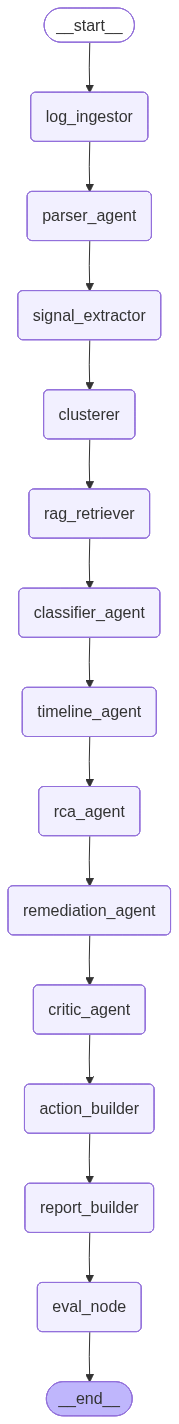

In [38]:
# Install graphviz first
!apt-get install -y graphviz libgraphviz-dev pkg-config -q
!pip install -q pygraphviz

import sys
for mod in list(sys.modules.keys()):
    if "incidentiq" in mod:
        del sys.modules[mod]

from incidentiq.orchestrator import build_graph
from IPython.display import Image, display

graph = build_graph()
png_bytes = graph.get_graph().draw_mermaid_png()
display(Image(png_bytes))